In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from Autograd import Tensor
from Loss import cross_entropy_loss
from Transformer import Transformer
from Optimiser import Adam,warmup_cosine_scheduler
from Training import text_training,text_generate_batch
from Tiny_Shakespeare_Data_Prep import data_read,generate_dataset
from Model_saving import save_model,load_model

In [3]:
block_size=32
embedding_dim=32
no_heads=4
hidden_dim=128
no_blocks=2

epochs=20
steps_per_epoch=500
batch_size=128

In [4]:
vocab_size,encode_dict,decode_dict,train_tokens,test_tokens=data_read(split=0.7)

In [5]:
model=Transformer(embedding_dim=embedding_dim,no_heads=no_heads,vocab_size=vocab_size,block_size=block_size,hidden_dim=hidden_dim,no_blocks=no_blocks)
loss_fn=cross_entropy_loss
optimiser=Adam(params=model.parameters(),lr=0.001,beta1=0.9,beta2=0.999,epsilon=1e-8)
lr_schedule=warmup_cosine_scheduler(optimiser,500,epochs*steps_per_epoch)

In [26]:
loss=text_training(train_tokens,model,loss_fn,epochs,steps_per_epoch,optimiser,batch_size,block_size)

Epoch  1  loss:  2.456724621276332
Epoch  2  loss:  2.0509060919882103
Epoch  3  loss:  1.943250073632211
Epoch  4  loss:  1.8872452047703567
Epoch  5  loss:  1.8545154785958984
Epoch  6  loss:  1.8300344784598856
Epoch  7  loss:  1.8109839013170377
Epoch  8  loss:  1.7956550173226793
Epoch  9  loss:  1.7846191809456744
Epoch  10  loss:  1.7716538813664116
Epoch  11  loss:  1.7634858126985198
Epoch  12  loss:  1.7577638246304281
Epoch  13  loss:  1.7471490206114006
Epoch  14  loss:  1.7403622289938652
Epoch  15  loss:  1.7318827487720139
Epoch  16  loss:  1.7281592590553032
Epoch  17  loss:  1.7225408785488192
Epoch  18  loss:  1.7178312359615633
Epoch  19  loss:  1.710811510872291
Epoch  20  loss:  1.7076124153752992


1.7076124153752992


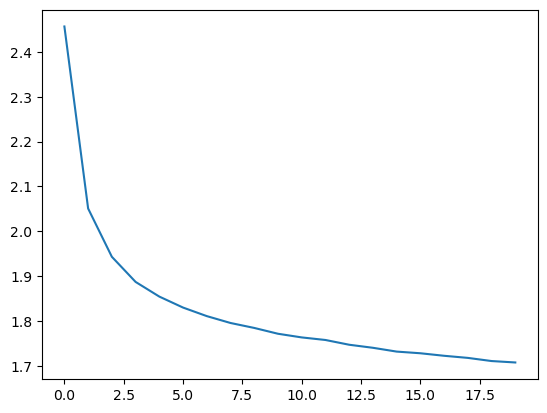

In [27]:
training_loss=loss[-1]
plt.plot(loss)
print(training_loss)

In [28]:
save_model(model,"transformer_weights.npy")

In [6]:
load_model(model,"transformer_weights.npy")

In [7]:
test_ins,test_out=generate_dataset(test_tokens[:5000],block_size)
logits=model.forward_prop(test_ins)
test_loss=cross_entropy_loss(logits,test_out)
print(test_loss.data)

1.9450913034600317


In [8]:
def generate_text(model,prompt,encode_dict,decode_dict,max_tokens=200,block_size=64,adjustment=1.0):
    # Encode prompt
    tokens=[encode_dict[ch] for ch in prompt]
    for i in range(max_tokens):
        context=tokens[-block_size:]
        x=Tensor(np.array([context]))
        logits=model.forward_prop(x)
        logits=logits.data[0,-1,:]
        logits=logits/adjustment
        logits=logits-np.max(logits)
        probs=np.exp(logits)
        probs=probs/np.sum(probs)
        next_token=np.random.choice(len(probs),p=probs)
        tokens.append(next_token)
    return "".join([decode_dict[t] for t in tokens])

In [10]:
iterations=1
prompt="Juliet! "

for i in range(iterations):
    print(generate_text(model,prompt,encode_dict,decode_dict,500,block_size))

Juliet! Berek
An one gealt subut, wickeet will arre
Is myoult:
Not Rome, Grementing our me dackend hare have is weps armon!
Go, my kinger look mannable the was you,
Shy you poingle'd as frecten marry when vanry?

WARWICK:
So show wo maust upon to torgen lest out,
Can,
if end in the mou masteret! O them king ut by of
But grain
To in heave
till unted whine, and toling oldrengrialf, af--foming of the sorraves gue a edest anot wost fire come scored.
She huse should intrans age, my roantlabeg a lought, wer a
